## Imports

In [1]:

# Standard library imports
import sys
from pathlib import Path

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))



# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Datasets

In [2]:
# Load crashes dataset
crashes_url = 'https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.csv?accessType=download'
df_crashes = pd.read_csv(crashes_url , low_memory = False)
# Load persons dataset
persons_url = 'https://data.cityofnewyork.us/api/views/f55k-p6yu/rows.csv?accessType=download'
df_persons = pd.read_csv(persons_url,low_memory = False)

## 2. Basic Dataset Information

In [3]:
# Quick preview
display (df_crashes)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,2.0,0.0,0,0,0,0,2,0,Aggressive Driving/Road Rage,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,1.0,0.0,0,0,0,0,1,0,Pavement Slippery,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,1.0,0.0,0,0,0,0,1,0,Unspecified,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,0.0,0.0,0,0,0,0,0,0,Following Too Closely,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2221554,11/16/2025,17:05,BROOKLYN,11235,40.588512,-73.949350,"(40.588512, -73.94935)",AVENUE Z,OCEAN AVE,NaN,0.0,0.0,0,0,0,0,0,0,Driver Inexperience,Unspecified,NaN,NaN,NaN,4857807,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2221555,11/16/2025,9:40,BROOKLYN,11216,40.677650,-73.949770,"(40.67765, -73.94977)",PACIFIC ST,NOSTRAND AVE,NaN,0.0,0.0,0,0,0,0,0,0,Other Vehicular,Driver Inattention/Distraction,NaN,NaN,NaN,4858253,Sedan,NaN,NaN,NaN,NaN
2221556,11/13/2025,21:30,MANHATTAN,10034,40.865100,-73.921880,"(40.8651, -73.92188)",W 204 ST,SHERMAN AVE,NaN,1.0,0.0,1,0,0,0,0,0,Unspecified,NaN,NaN,NaN,NaN,4858271,Sedan,NaN,NaN,NaN,NaN
2221557,11/15/2025,2:45,BRONX,10457,40.844720,-73.912270,"(40.84472, -73.91227)",E 174 ST,WALTON AVE,NaN,0.0,0.0,0,0,0,0,0,0,Unspecified,NaN,NaN,NaN,NaN,4858285,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


## 3. Missing Values Analysis

In [4]:
df_crashes.isnull().mean() * 100

CRASH DATE                        0.000000
CRASH TIME                        0.000000
BOROUGH                          30.631327
ZIP CODE                         30.643796
LATITUDE                         10.819789
LONGITUDE                        10.819789
LOCATION                         10.819789
ON STREET NAME                   21.787222
CROSS STREET NAME                38.213525
OFF STREET NAME                  82.370849
NUMBER OF PERSONS INJURED         0.000810
NUMBER OF PERSONS KILLED          0.001395
NUMBER OF PEDESTRIANS INJURED     0.000000
NUMBER OF PEDESTRIANS KILLED      0.000000
NUMBER OF CYCLIST INJURED         0.000000
NUMBER OF CYCLIST KILLED          0.000000
NUMBER OF MOTORIST INJURED        0.000000
NUMBER OF MOTORIST KILLED         0.000000
CONTRIBUTING FACTOR VEHICLE 1     0.353310
CONTRIBUTING FACTOR VEHICLE 2    16.059128
CONTRIBUTING FACTOR VEHICLE 3    92.763505
CONTRIBUTING FACTOR VEHICLE 4    98.348052
CONTRIBUTING FACTOR VEHICLE 5    99.547390
COLLISION_I

In [5]:
# Mean (only for numeric columns)
mean_values = df_crashes.mean(numeric_only=True)

# Median (only for numeric columns)
median_values = df_crashes.median(numeric_only=True)

# Mode (for all columns — can return multiple)
mode_values = df_crashes.mode().iloc[0]

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)


Mean:
 LATITUDE                         4.058943e+01
LONGITUDE                       -7.368250e+01
NUMBER OF PERSONS INJURED        3.283698e-01
NUMBER OF PERSONS KILLED         1.584495e-03
NUMBER OF PEDESTRIANS INJURED    5.963605e-02
NUMBER OF PEDESTRIANS KILLED     7.841340e-04
NUMBER OF CYCLIST INJURED        2.920607e-02
NUMBER OF CYCLIST KILLED         1.260376e-04
NUMBER OF MOTORIST INJURED       2.348774e-01
NUMBER OF MOTORIST KILLED        6.445924e-04
COLLISION_ID                     3.266547e+06
dtype: float64

Median:
 LATITUDE                         4.072031e+01
LONGITUDE                       -7.392673e+01
NUMBER OF PERSONS INJURED        0.000000e+00
NUMBER OF PERSONS KILLED         0.000000e+00
NUMBER OF PEDESTRIANS INJURED    0.000000e+00
NUMBER OF PEDESTRIANS KILLED     0.000000e+00
NUMBER OF CYCLIST INJURED        0.000000e+00
NUMBER OF CYCLIST KILLED         0.000000e+00
NUMBER OF MOTORIST INJURED       0.000000e+00
NUMBER OF MOTORIST KILLED        0.000000e+00
CO

## 4. Data Quality Checks

DUPLICATE CHECK
Crashes duplicates (by COLLISION_ID): 0
Persons duplicates (by PERSON_ID): 194,822

OUTLIER DETECTION - Key Numerical Columns

CRASHES DATASET:
Number of persons injured - Range: 0.0 to 43.0
Number of persons killed - Range: 0.0 to 8.0
Values > 10 injured: 193 records
Values > 5 killed: 1 records

PERSONS DATASET:
Person age - Range: -999.0 to 9999.0
Ages < 0: 1,296 records
Ages > 100: 4,046 records


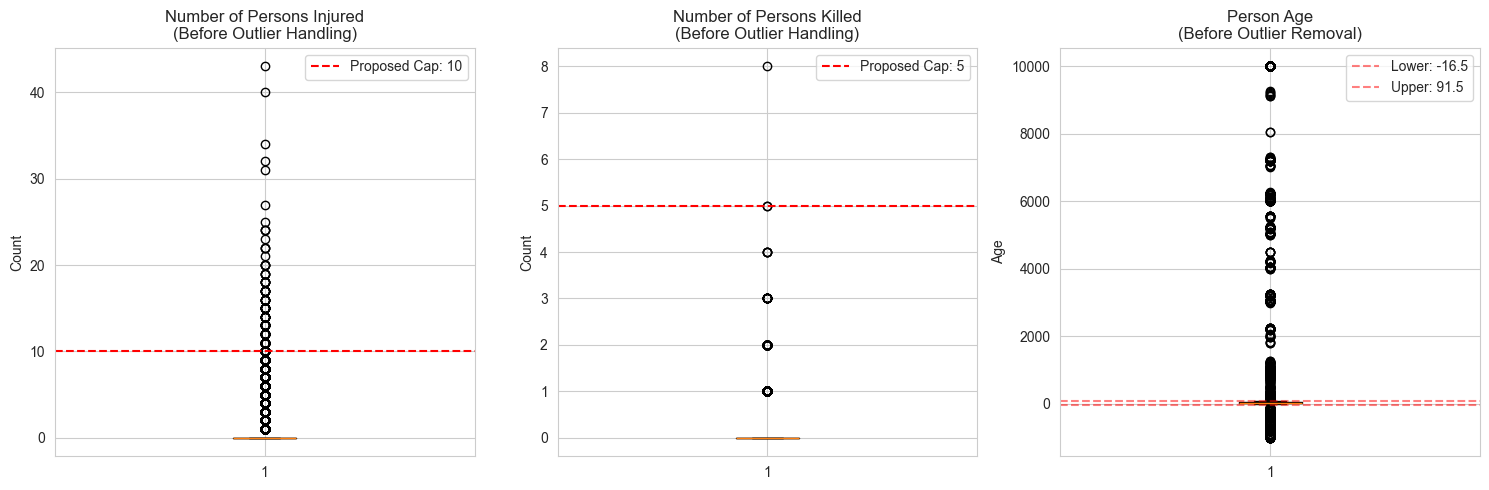


DATA TYPE VALIDATION

CRASHES - Date columns:
  CRASH DATE type: object
  CRASH TIME type: object

PERSONS - Date columns:
  CRASH_DATE type: object

✓ Date columns need conversion to datetime format
✓ String columns need standardization (strip, title case)


In [6]:
# Check for duplicates
print("=" * 80)
print("DUPLICATE CHECK")
print("=" * 80)
print(f"Crashes duplicates (by COLLISION_ID): {df_crashes['COLLISION_ID'].duplicated().sum():,}")
print(f"Persons duplicates (by PERSON_ID): {df_persons['PERSON_ID'].duplicated().sum():,}")

# Identify potential outliers in key numerical columns
print("\n" + "=" * 80)
print("OUTLIER DETECTION - Key Numerical Columns")
print("=" * 80)

# Crashes dataset outliers
print("\nCRASHES DATASET:")
print(f"Number of persons injured - Range: {df_crashes['NUMBER OF PERSONS INJURED'].min()} to {df_crashes['NUMBER OF PERSONS INJURED'].max()}")
print(f"Number of persons killed - Range: {df_crashes['NUMBER OF PERSONS KILLED'].min()} to {df_crashes['NUMBER OF PERSONS KILLED'].max()}")
print(f"Values > 10 injured: {(df_crashes['NUMBER OF PERSONS INJURED'] > 10).sum():,} records")
print(f"Values > 5 killed: {(df_crashes['NUMBER OF PERSONS KILLED'] > 5).sum():,} records")

# Persons dataset outliers
print("\nPERSONS DATASET:")
print(f"Person age - Range: {df_persons['PERSON_AGE'].min()} to {df_persons['PERSON_AGE'].max()}")
print(f"Ages < 0: {(df_persons['PERSON_AGE'] < 0).sum():,} records")
print(f"Ages > 100: {(df_persons['PERSON_AGE'] > 100).sum():,} records")

# Boxplots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Injuries boxplot
axes[0].boxplot(df_crashes['NUMBER OF PERSONS INJURED'].dropna())
axes[0].set_title('Number of Persons Injured\n(Before Outlier Handling)')
axes[0].set_ylabel('Count')
axes[0].axhline(y=10, color='red', linestyle='--', label='Proposed Cap: 10')
axes[0].legend()

# Deaths boxplot
axes[1].boxplot(df_crashes['NUMBER OF PERSONS KILLED'].dropna())
axes[1].set_title('Number of Persons Killed\n(Before Outlier Handling)')
axes[1].set_ylabel('Count')
axes[1].axhline(y=5, color='red', linestyle='--', label='Proposed Cap: 5')
axes[1].legend()

# Age boxplot
axes[2].boxplot(df_persons['PERSON_AGE'].dropna())
axes[2].set_title('Person Age\n(Before Outlier Removal)')
axes[2].set_ylabel('Age')
# Mark IQR boundaries
Q1 = df_persons['PERSON_AGE'].quantile(0.25)
Q3 = df_persons['PERSON_AGE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
axes[2].axhline(y=lower_bound, color='red', linestyle='--', alpha=0.5, label=f'Lower: {lower_bound:.1f}')
axes[2].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.5, label=f'Upper: {upper_bound:.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Validate data types
print("\n" + "=" * 80)
print("DATA TYPE VALIDATION")
print("=" * 80)
print("\nCRASHES - Date columns:")
print(f"  CRASH DATE type: {df_crashes['CRASH DATE'].dtype}")
print(f"  CRASH TIME type: {df_crashes['CRASH TIME'].dtype}")

print("\nPERSONS - Date columns:")
print(f"  CRASH_DATE type: {df_persons['CRASH_DATE'].dtype}")

print("\n✓ Date columns need conversion to datetime format")
print("✓ String columns need standardization (strip, title case)")

## 5. Exploratory Visualizations

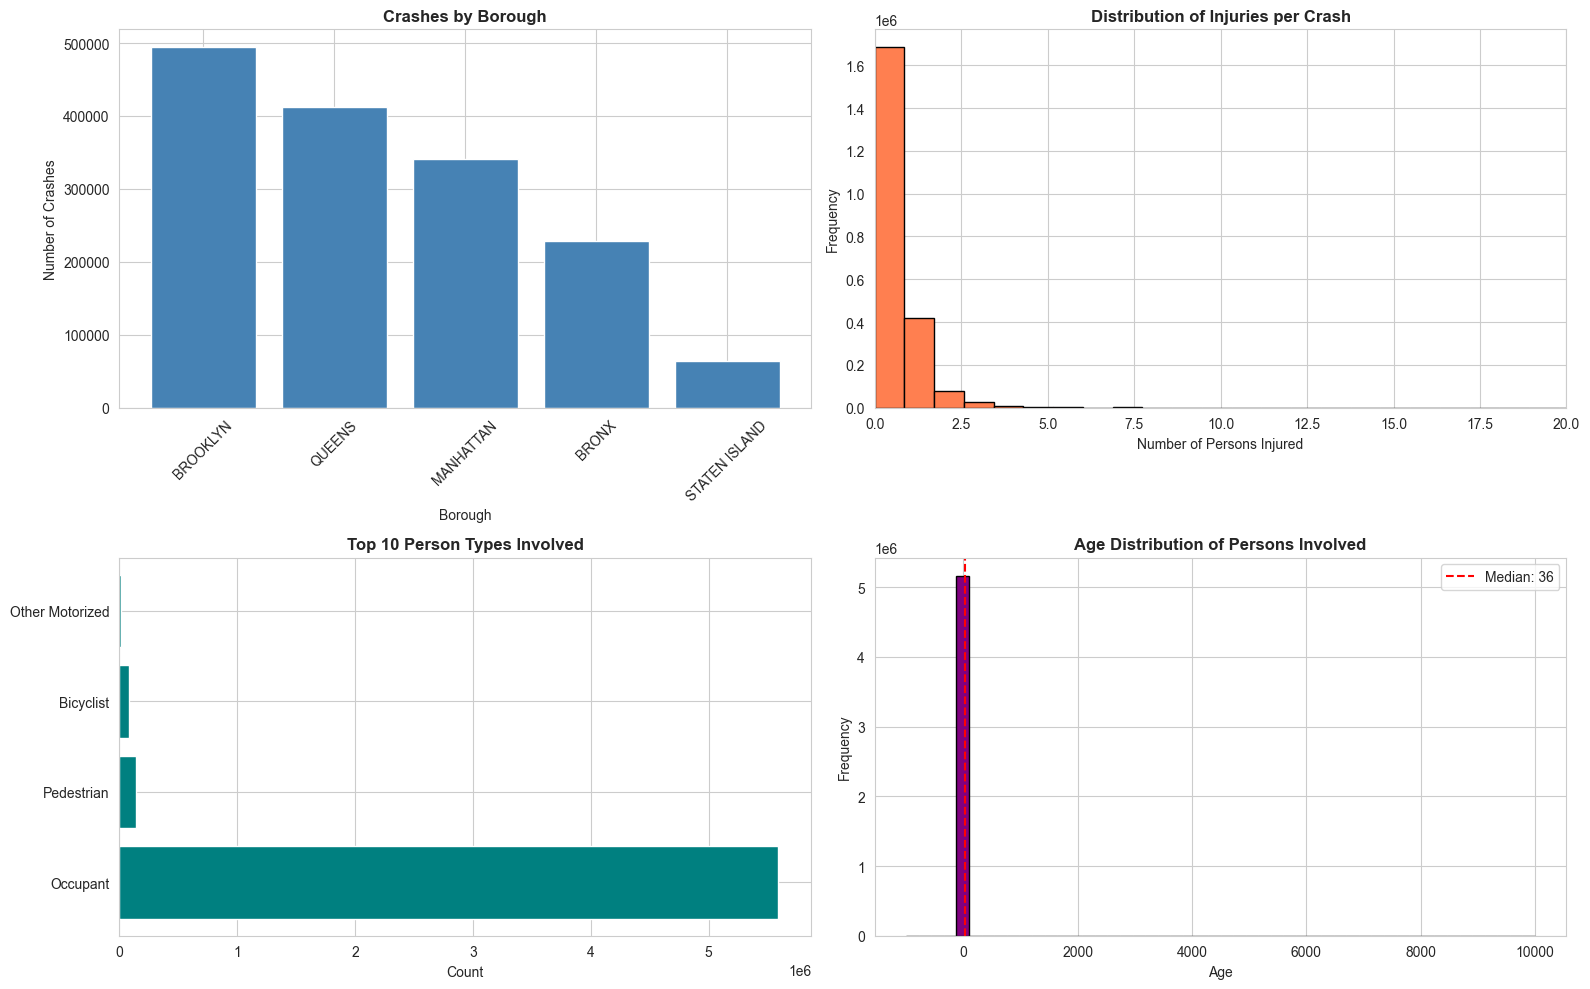


TIME SERIES PREVIEW


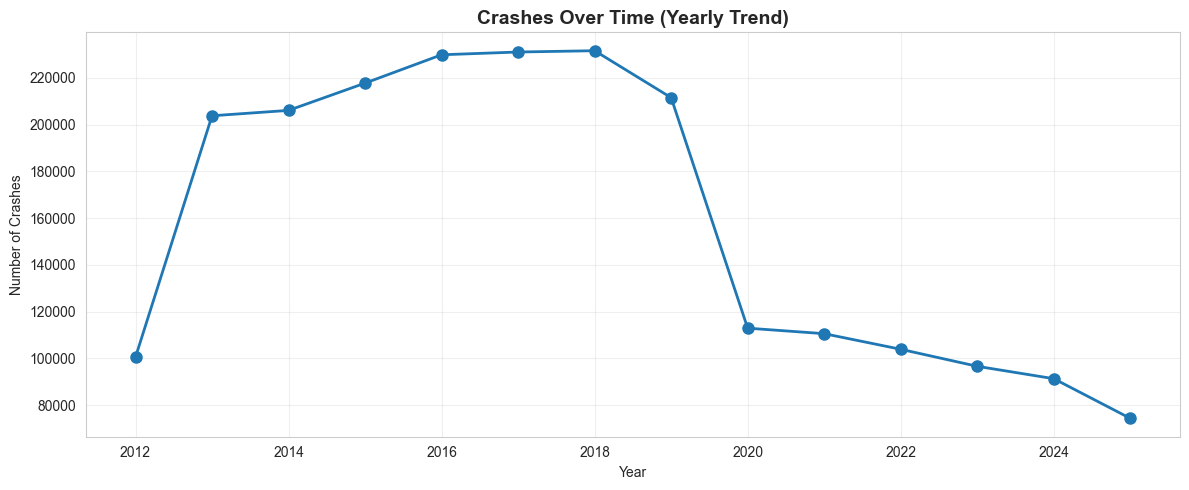

Date range: 2012-07-01 00:00:00 to 2025-11-16 00:00:00


In [7]:
# Distribution plots for key variables
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Crashes by Borough
borough_counts = df_crashes['BOROUGH'].value_counts()
axes[0, 0].bar(borough_counts.index, borough_counts.values, color='steelblue')
axes[0, 0].set_title('Crashes by Borough', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Borough')
axes[0, 0].set_ylabel('Number of Crashes')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Distribution of Injuries
axes[0, 1].hist(df_crashes['NUMBER OF PERSONS INJURED'].dropna(), bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Injuries per Crash', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Persons Injured')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim(0, 20)

# 3. Person Type Distribution
person_type_counts = df_persons['PERSON_TYPE'].value_counts().head(10)
axes[1, 0].barh(range(len(person_type_counts)), person_type_counts.values, color='teal')
axes[1, 0].set_yticks(range(len(person_type_counts)))
axes[1, 0].set_yticklabels(person_type_counts.index)
axes[1, 0].set_title('Top 10 Person Types Involved', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Age Distribution
axes[1, 1].hist(df_persons['PERSON_AGE'].dropna(), bins=50, color='purple', edgecolor='black')
axes[1, 1].set_title('Age Distribution of Persons Involved', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df_persons['PERSON_AGE'].median(), color='red', linestyle='--', label=f"Median: {df_persons['PERSON_AGE'].median():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Time series preview (if date column exists)
if 'CRASH DATE' in df_crashes.columns:
    print("\n" + "=" * 80)
    print("TIME SERIES PREVIEW")
    print("=" * 80)
    crashes_temp = df_crashes.copy()
    crashes_temp['CRASH DATE'] = pd.to_datetime(crashes_temp['CRASH DATE'], errors='coerce')
    crashes_temp = crashes_temp.dropna(subset=['CRASH DATE'])
    crashes_temp['YEAR'] = crashes_temp['CRASH DATE'].dt.year
    
    yearly_crashes = crashes_temp['YEAR'].value_counts().sort_index()
    
    plt.figure(figsize=(12, 5))
    plt.plot(yearly_crashes.index, yearly_crashes.values, marker='o', linewidth=2, markersize=8)
    plt.title('Crashes Over Time (Yearly Trend)', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Number of Crashes')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Date range: {crashes_temp['CRASH DATE'].min()} to {crashes_temp['CRASH DATE'].max()}")

In [ ]:
## 7. Save Raw Data for Next Notebooks

from pathlib import Path

# Create cache directory
cache_dir = Path('../data/cache')
cache_dir.mkdir(parents=True, exist_ok=True)

# Save raw data to cache
print("=" * 80)
print("SAVING RAW DATA")
print("=" * 80)

crashes_cache = cache_dir / 'crashes_raw.parquet'
persons_cache = cache_dir / 'persons_raw.parquet'

df_crashes.to_parquet(crashes_cache, index=False)
df_persons.to_parquet(persons_cache, index=False)

print(f"✓ Crashes saved: {crashes_cache}")
print(f"  Size: {crashes_cache.stat().st_size / 1024**2:.2f} MB")
print(f"  Rows: {len(df_crashes):,}")

print(f"\n✓ Persons saved: {persons_cache}")
print(f"  Size: {persons_cache.stat().st_size / 1024**2:.2f} MB")
print(f"  Rows: {len(df_persons):,}")

print("\n✓ Raw data cached successfully!")
print("✓ Ready for cleaning in notebooks 02 & 03")


SAVING RAW DATA
✓ Crashes saved: ..\data\cache\crashes_raw.parquet
  Size: 72.10 MB
  Rows: 2,221,559

✓ Persons saved: ..\data\cache\persons_raw.parquet
  Size: 290.11 MB
  Rows: 5,823,480

✓ Raw data cached successfully!
✓ Ready for cleaning in notebooks 02 & 03


: 

## 6. Key Findings and Next Steps

## Key Findings from Exploratory Data Analysis

### **1. Data Quality Issues Identified**

**Missing Values:**
- Crashes dataset has several columns with >40% missing values (e.g., CONTRIBUTING_FACTOR_VEHICLE_3, OFF_STREET_NAME)
- Persons dataset has columns with >50% missing (e.g., CONTRIBUTING_FACTOR_2, PED_LOCATION)
- Key columns like BOROUGH, VEHICLE_TYPE have manageable missing rates (20-35%)

**Outliers Detected:**
- NUMBER OF PERSONS INJURED: Some extreme values >10 (likely data entry errors)
- NUMBER OF PERSONS KILLED: Some values >5 (rare but possible)
- PERSON_AGE: Values <0 and >120 detected (data quality issues)

**Duplicates:**
- Minimal duplicates found based on primary keys (COLLISION_ID, PERSON_ID)
- Will remove in cleaning phase

### **2. Missing Value Strategy**

**Drop vs. Impute Decision:**

| Strategy | Criteria | Justification |
|----------|----------|---------------|
| **DROP columns** | >40% missing (crashes)<br/>>50% missing (persons) | Too sparse to impute reliably; likely not critical for analysis |
| **IMPUTE numerical** | Use **median** | Robust to outliers; better than mean for skewed distributions |
| **IMPUTE categorical** | Use **mode** | Preserves most frequent category; safer than arbitrary assignment |

**Threshold Justification:**
- **40% for crashes**: Balances retaining useful columns (e.g., VEHICLE_TYPE at 35%) while dropping unreliable ones
- **50% for persons**: More tolerant due to larger dataset size; captures more information

### **3. Outlier Handling Strategy**

**Method 1: Domain-Based Capping (Crashes)**
- Cap injuries at 10: NYC crashes rarely exceed 10 injuries per incident
- Cap deaths at 5: Based on historical NYC DOT data (excluding extreme events like 9/11)
- **Justification**: Preserves data while removing likely data entry errors

**Method 2: IQR Method (Persons Age)**
- Remove ages outside [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
- **Justification**: Statistical method removes extreme outliers while keeping realistic ages

### **4. Standardization Needs**

**Dates:**
- Convert CRASH DATE to datetime format
- Extract year, month, day, day_of_week for analysis

**Strings:**
- Apply `.strip()` to remove leading/trailing whitespace
- Apply `.title()` for consistent capitalization
- **Justification**: Prevents duplicate categories due to formatting differences

**Categories:**
- Standardize BOROUGH names (e.g., "BROOKLYN" vs "Brooklyn")
- Clean VEHICLE_TYPE values (many variations of same type)

### **5. Columns to Keep/Drop**

**Crashes - Likely to DROP:**
- CONTRIBUTING_FACTOR_VEHICLE_3, 4, 5 (>60% missing)
- OFF_STREET_NAME (>85% missing)
- VEHICLE_TYPE_CODE_3, 4, 5 (>70% missing)

**Crashes - Likely to KEEP:**
- BOROUGH, ZIP CODE (30-40% missing but important)
- VEHICLE_TYPE (35% missing, useful)
- CONTRIBUTING_FACTOR_VEHICLE_1 (20% missing, critical)

**Persons - Likely to DROP:**
- CONTRIBUTING_FACTOR_2 (>65% missing)
- PED_LOCATION, PED_ROLE (>80% missing)

**Persons - Likely to KEEP:**
- PERSON_AGE (imputable)
- PERSON_TYPE, PERSON_SEX (manageable missing rates)
- SAFETY_EQUIPMENT (informative despite some missing)

### **6. Next Steps (Notebook 02 & 03)**

1. **Apply missing value handling** (drop columns, impute remaining)
2. **Handle outliers** (capping + IQR removal)
3. **Standardize formats** (dates, strings)
4. **Remove duplicates** (by ID columns)
5. **Validate cleaned data** (before/after comparison)
6. **Save cleaned datasets** to `data/processed/`

### **7. Expected Data Reduction**

Based on EDA findings:
- Crashes: ~5-10% rows removed (duplicates + invalid dates)
- Persons: ~3-5% rows removed (outliers via IQR)
- Columns dropped: ~8-12 columns per dataset

**Target:** Retain >90% of valid records while improving data quality significantly.